# Análise de dados do dadaset

Análise dos dados obtidos através de vídeos públicos disponíveis no YouTube.
Informações e links de acesso disponíveis em : _./data/info.txt_

In [20]:
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np

In [21]:
path_car_dataset = "./output_dataset/cars_dataset.csv"
path_plates_dataset = "./output_dataset/plates_dataset.csv"
path_ocrs_dataset = "./output_dataset/ocrs_dataset.csv"

df_car_dataset = pd.read_csv(path_car_dataset)
df_plates_dataset = pd.read_csv(path_plates_dataset)
df_ocrs_dataset = pd.read_csv(path_ocrs_dataset)

### Dataset de carros coletados

In [22]:
print(f" car_dataset | shape {df_car_dataset.shape[0]}x{df_car_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_car_dataset.isna().sum()}")

 car_dataset | shape 136249x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [23]:
display(df_car_dataset.head())
df_car_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,car_ba7b0d6e,368,"(2208, 842, 2995, 1114)",carro,0.917167,natal.webm
1,car_a3c44635,371,"(2079, 845, 2826, 1114)",carro,0.937612,natal.webm
2,car_5c9ed4e8,484,"(326, 1797, 1349, 2144)",carro,0.954534,natal.webm
3,car_4b8a9ed2,485,"(328, 1796, 1348, 2144)",carro,0.962618,natal.webm
4,car_ed6bb045,486,"(327, 1794, 1370, 2143)",carro,0.963621,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 136249 entries, 0 to 136248
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            136249 non-null  str    
 1   id_font       136249 non-null  int64  
 2   bbox          136249 non-null  str    
 3   label         136249 non-null  str    
 4   conf          136249 non-null  float64
 5   source_video  136249 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 6.2 MB


### Dataset de placas coletadas

In [24]:
print(f" car_dataset | shape {df_plates_dataset.shape[0]}x{df_plates_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_plates_dataset.isna().sum()}")

 car_dataset | shape 116437x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [25]:
display(df_plates_dataset.head())
df_plates_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,plt_85f5b30b,car_90dca11b,"(6, 288, 102, 326)",nova,0.936701,natal.webm
1,plt_39ef23a3,car_8ff59093,"(95, 269, 196, 306)",antiga,0.999683,natal.webm
2,plt_1442f177,car_0a3640ac,"(106, 267, 214, 306)",antiga,0.999352,natal.webm
3,plt_5f63d169,car_e1ef34f4,"(73, 271, 184, 310)",antiga,0.999050,natal.webm
4,plt_89bc1b47,car_38ec2e74,"(20, 294, 129, 334)",antiga,0.998928,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 116437 entries, 0 to 116436
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            116437 non-null  str    
 1   id_font       116437 non-null  str    
 2   bbox          116437 non-null  str    
 3   label         116437 non-null  str    
 4   conf          116437 non-null  float64
 5   source_video  116437 non-null  str    
dtypes: float64(1), str(5)
memory usage: 5.3 MB


### Dataset de placas identificadas

In [26]:
print(f" car_dataset | shape {df_ocrs_dataset.shape[0]}x{df_ocrs_dataset.shape[1]}")
print(f" car_dataset | valores ausentes: \n {df_ocrs_dataset.isna().sum()}")

 car_dataset | shape 78721x6
 car_dataset | valores ausentes: 
 id              0
id_font         0
bbox            0
label           0
conf            0
source_video    0
dtype: int64


In [27]:
display(df_ocrs_dataset.head())
df_ocrs_dataset.info()
#bbox relativo ao input do video

,id,id_font,bbox,label,conf,source_video
0,ocr_1f149d4f,plt_37ea9f5f,"(577, 311, 714, 354)",OJT3H79,0.990956,natal.webm
1,ocr_2f0e9d9d,plt_b118571f,"(633, 325, 787, 369)",OJT3H79,0.997838,natal.webm
2,ocr_87154596,plt_705e11e7,"(658, 326, 813, 376)",OJT3H79,0.999050,natal.webm
3,ocr_3aa7fab4,plt_98fb7013,"(129, 170, 206, 197)",OGY2273,0.991133,natal.webm
4,ocr_0c0382a9,plt_86aa0a0b,"(139, 176, 215, 205)",YGV2273,0.998049,natal.webm


<class 'pandas.DataFrame'>
RangeIndex: 78721 entries, 0 to 78720
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            78721 non-null  str    
 1   id_font       78721 non-null  str    
 2   bbox          78721 non-null  str    
 3   label         78721 non-null  str    
 4   conf          78721 non-null  float64
 5   source_video  78721 non-null  str    
dtypes: float64(1), str(5)
memory usage: 3.6 MB


In [28]:
#verifica a quantidade de placas unicas
total_placas = df_ocrs_dataset['label'].nunique()
_placas_count = df_ocrs_dataset['label'].value_counts()
media_placas_duplicadas = _placas_count.mean()
min_placas_duplicadas = _placas_count.min()
max_placas_duplicadas = _placas_count.max()

print(f"Placas unicas: {total_placas}")
print(f"Placas media de duplicadas: {media_placas_duplicadas}")
print(f"Placas minima de duplicadas: {min_placas_duplicadas}")
print(f"Placas maxima de duplicadas: {max_placas_duplicadas}")

Placas unicas: 570
Placas media de duplicadas: 138.10701754385966
Placas minima de duplicadas: 1
Placas maxima de duplicadas: 12108


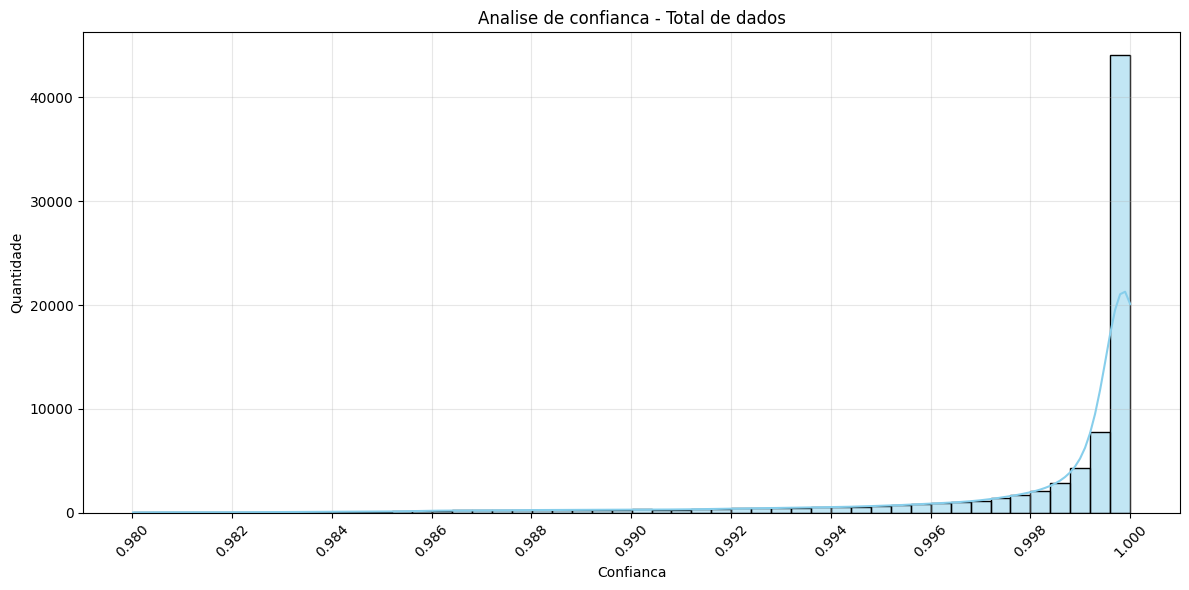

In [34]:
# Distribuicao de confianca total
plt.figure(figsize=(12, 6))

# Filtro maior que 0.98
data_filtro = df_ocrs_dataset[df_ocrs_dataset['conf'] >= 0.98]

sns.histplot(data_filtro['conf'], bins=50, kde=True, color='skyblue')

ticks = np.linspace(0.98, 1.00, 11)
plt.xticks(ticks, [f"{t:.3f}" for t in ticks], rotation=45)

plt.title('Analise de confianca - Total de dados')
plt.xlabel('Confianca')
plt.ylabel('Quantidade')
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

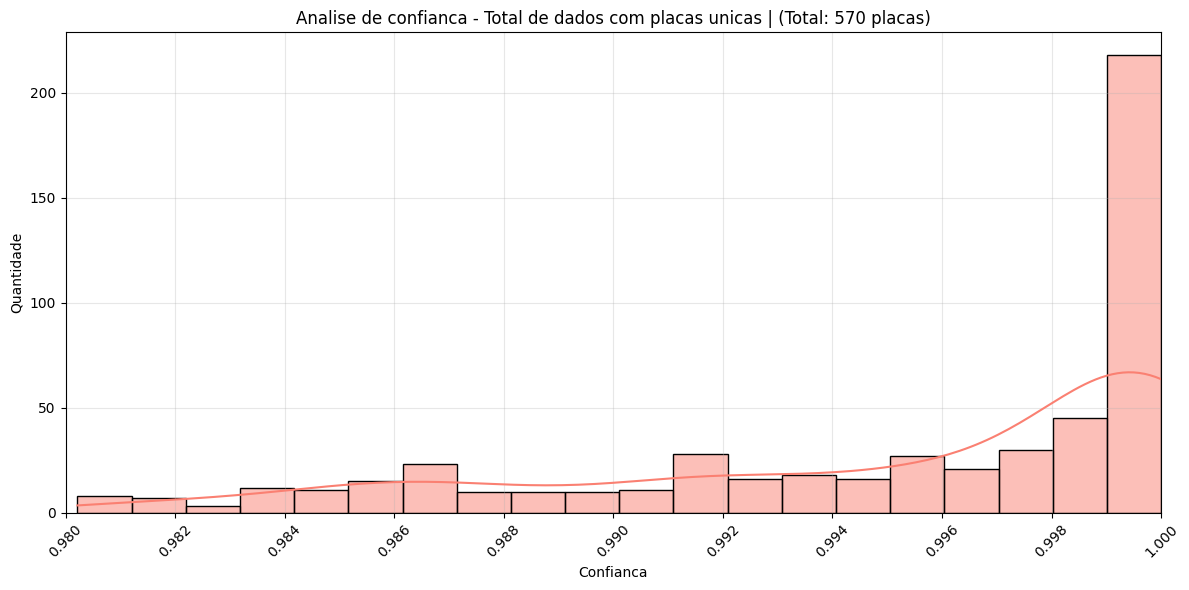

In [35]:
# Distribuicao de confianca total com dados unicos
plt.figure(figsize=(12, 6))

# Filtro placas unicas
df_labels_unicos = df_ocrs_dataset.sort_values('conf', ascending=False).drop_duplicates('label')
# Filtro maior que 0.98
data_filtro = df_labels_unicos[df_labels_unicos['conf'] >= 0.98]


sns.histplot(data_filtro['conf'], bins=20, kde=True, color='salmon')
plt.xlim(0.98, 1.00)
ticks = np.linspace(0.98, 1.00, 11)
plt.xticks(ticks, [f"{t:.3f}" for t in ticks], rotation=45)

plt.title(f'Analise de confianca - Total de dados com placas unicas | (Total: {len(df_labels_unicos)} placas)')
plt.xlabel('Confianca')
plt.ylabel('Quantidade')
plt.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()

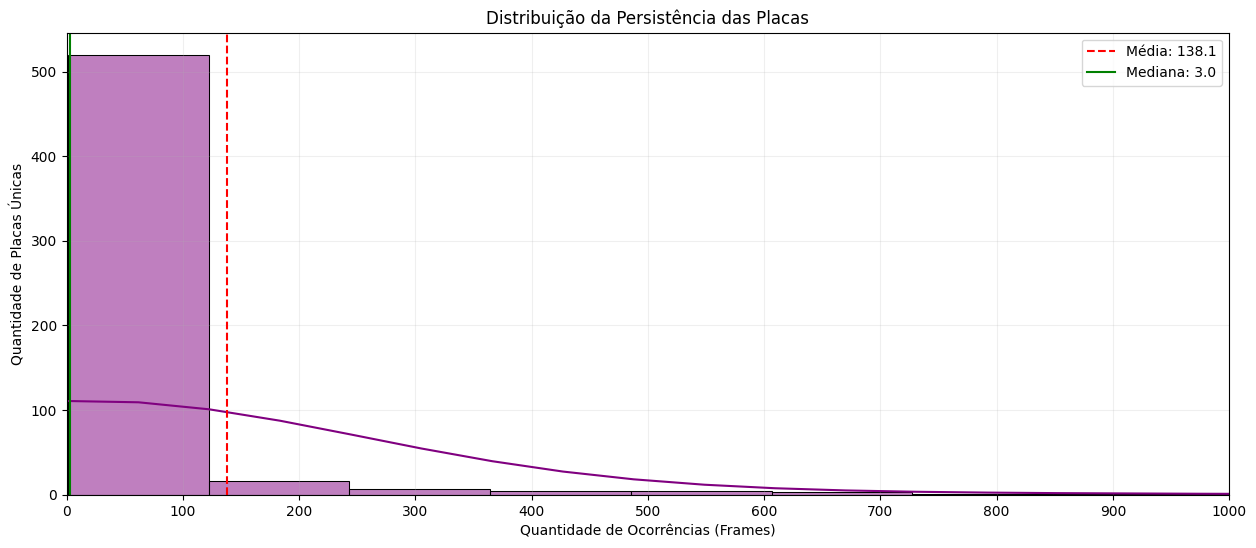

In [49]:
#Calculo da frequência (contagem de frames por placa)
contagem_placas = df_ocrs_dataset['label'].value_counts().reset_index()
contagem_placas.columns = ['label', 'frequencia']

plt.figure(figsize=(15, 6))

sns.histplot(contagem_placas['frequencia'], bins=100, kde=True, color='purple')
plt.xlim(0, 1000)
plt.xticks(np.arange(0, 1001, 100))

# 5. Linhas de referência (Média  Mediana)
media = contagem_placas['frequencia'].mean()
mediana = contagem_placas['frequencia'].median()
plt.axvline(media, color='red', linestyle='--', label=f'Média: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.1f}')

plt.title('Distribuição da Persistência das Placas')
plt.xlabel('Quantidade de Ocorrências (Frames)')
plt.ylabel('Quantidade de Placas Únicas')
plt.legend()
plt.grid(axis='both', alpha=0.2)

plt.show()

In [53]:
# placas com conf entre 0.98 e 1.00
df_conf_filtrado = df_ocrs_dataset[(df_ocrs_dataset['conf'] >= 0.98) & (df_ocrs_dataset['conf'] <= 1.00)]

# ocorrencia de placas
contagem_por_label = df_conf_filtrado['label'].value_counts()

# filtra por quantidade de placas
labels_finais = contagem_por_label[(contagem_por_label >= 10) & (contagem_por_label <= 20000)]

print(f"Existem {len(labels_finais)} placas únicas que atendem aos dois critérios simultaneamente.")


Existem 204 placas únicas que atendem aos dois critérios simultaneamente.
